USE ```python -m``` (on windows) or ```python3 -m``` (on linux) + ```pip install -r required_libs.txt``` to install all necessary libraries!

Initial code

In [30]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt, lfilter, iirnotch
import pywt

# Parameters
sampling_rate = 2400  # Hz
fs = sampling_rate

# Find all relevant files
csv_files_anterior = sorted(glob.glob("anterior_*.csv"))
csv_files_posterior = sorted(glob.glob("posterior_*.csv"))
csv_all_motions_in_succession = "all_motions_in_succession_anterior.csv"

In case of Anterior and Posterior sets all movements have been repeated 5 times.

In case of motions performed in succession the pattern was: (**grip, thumb, index, middle, ring, pinky, flex, grip**)

CWT posterior muscles (prostowniki)

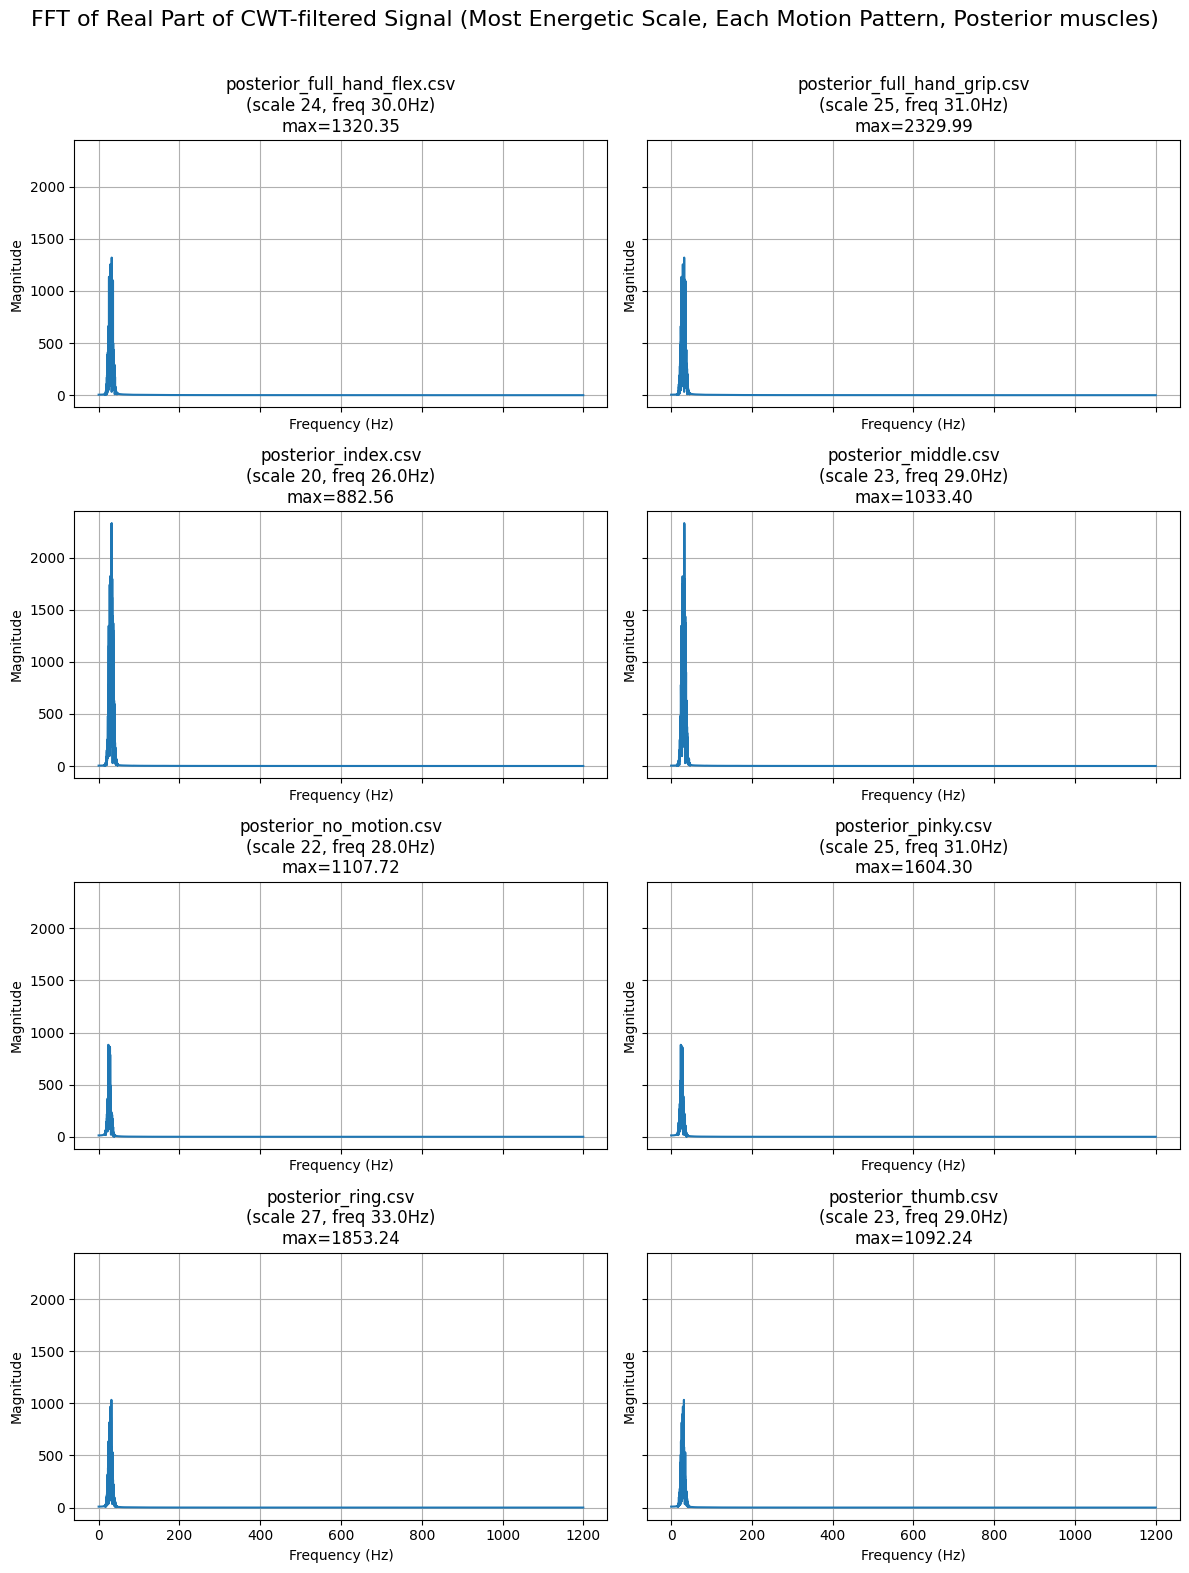

In [31]:
import math

cwt_fft_data = []
cwt_fft_freqs = []
cwt_labels = []
selected_scales = []

for filename in csv_files_posterior:
    adc_values = pd.read_csv(filename, header=None).squeeze()
    adc_values = adc_values[100:].reset_index(drop=True)
    
    # Filtering
        # FFC
    def comb_filter(signal, delay, alpha):
        b = np.zeros(delay + 1)
        b[0] = 1
        b[-1] = -alpha
        a = [1]
        return lfilter(b, a, signal)
    delay = int(fs / 50)
    alpha = 0.95
    filtered_signal_FFC = comb_filter(adc_values, delay, alpha)
        # Bandpass
    lowcut = 20.0
    highcut = 500.0
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(4, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, filtered_signal_FFC)
        # CWT
    B = 1.5
    C = 1.0
    wavelet = 'cmor'+str(B)+'-'+str(C)
    dt = 1/fs
    all_frequencies = np.arange(6, 500)
    frequencies = all_frequencies / fs
    scales = pywt.frequency2scale(wavelet, frequencies)
    cwtmatr, freqs = pywt.cwt(filtered_signal, scales, wavelet, sampling_period=dt)
    # Find the scale with the highest mean absolute value
    mean_abs = np.mean(np.abs(cwtmatr), axis=1)
    best_scale_idx = np.argmax(mean_abs)
    selected_scales.append(best_scale_idx)
    real_cwt = np.real(cwtmatr[best_scale_idx, :])
    # FFT of real CWT
    n = len(real_cwt)
    fft_signal = np.fft.fft(real_cwt)
    fft_freq = np.fft.fftfreq(n, d=1/fs)
    cwt_fft_data.append(np.abs(fft_signal)[:n//2])
    cwt_fft_freqs.append(fft_freq[:n//2])
    fft_magnitude = np.abs(fft_signal)[:n//2]
    max_magnitude = np.max(fft_magnitude)
    cwt_fft_data.append(fft_magnitude)
    cwt_fft_freqs.append(fft_freq[:n//2])
    cwt_labels.append(f"{filename}\n(scale {best_scale_idx}, freq {freqs[best_scale_idx]:.1f}Hz)\nmax={max_magnitude:.2f}")

# Plot all CWT-real FFTs in separate subplots
num_files = len(csv_files_posterior)
cols = 2
rows = math.ceil(num_files / cols)

fig, axs = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), sharex=True, sharey=True)
axs = axs.flatten()

for i in range(num_files):
    axs[i].plot(cwt_fft_freqs[i], cwt_fft_data[i])
    axs[i].set_title(cwt_labels[i])
    axs[i].set_xlabel("Frequency (Hz)")
    axs[i].set_ylabel("Magnitude")
    axs[i].grid(True)

# Hide any unused subplots
for j in range(num_files, len(axs)):
    fig.delaxes(axs[j])

fig.suptitle("FFT of Real Part of CWT-filtered Signal (Most Energetic Scale, Each Motion Pattern, Posterior muscles)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

CWT Anterior muscles (zginacze)

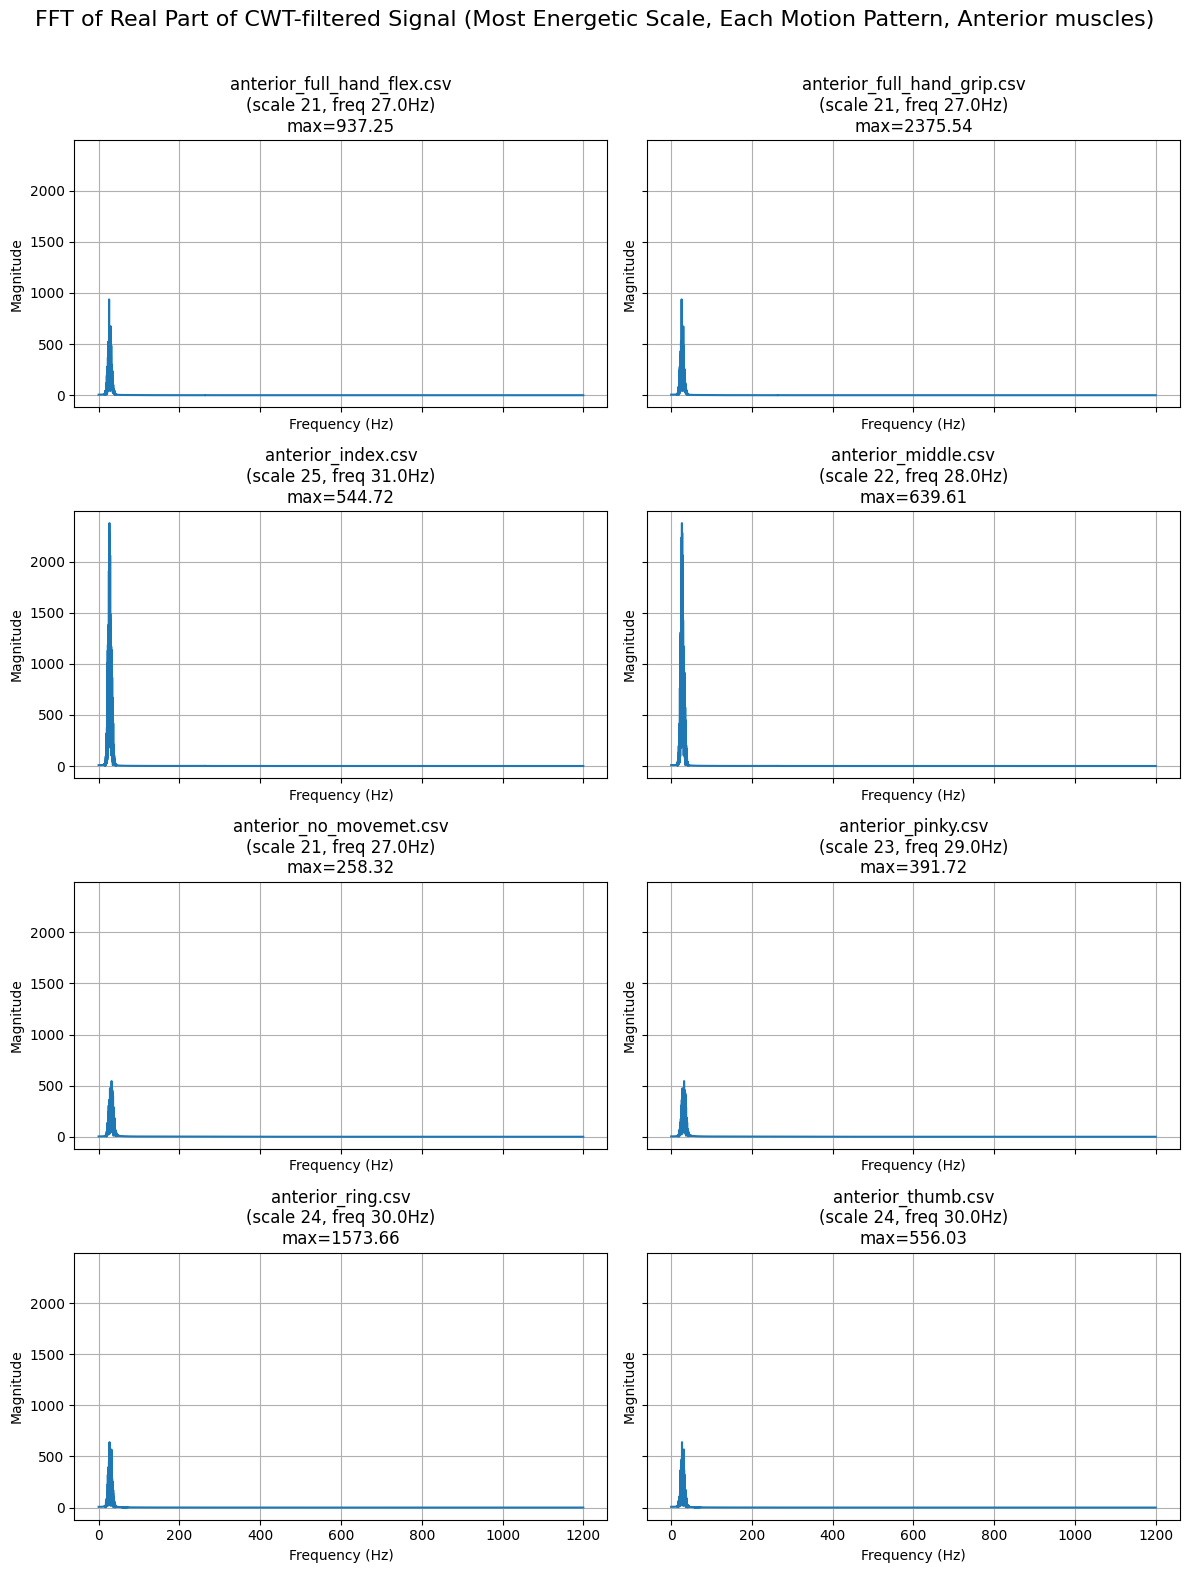

In [32]:
import math

cwt_fft_data = []
cwt_fft_freqs = []
cwt_labels = []
selected_scales = []

for filename in csv_files_anterior:
    adc_values = pd.read_csv(filename, header=None).squeeze()
    adc_values = adc_values[100:].reset_index(drop=True)
    # Filtering
        # FFC
    def comb_filter(signal, delay, alpha):
        b = np.zeros(delay + 1)
        b[0] = 1
        b[-1] = -alpha
        a = [1]
        return lfilter(b, a, signal)
    delay = int(fs / 50)
    alpha = 0.95
    filtered_signal_FFC = comb_filter(adc_values, delay, alpha)
        # Bandpass
    lowcut = 20.0
    highcut = 500.0
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(4, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, filtered_signal_FFC)
        # CWT
    B = 1.5
    C = 1.0
    wavelet = 'cmor'+str(B)+'-'+str(C)
    dt = 1/fs
    all_frequencies = np.arange(6, 500)
    frequencies = all_frequencies / fs
    scales = pywt.frequency2scale(wavelet, frequencies)
    cwtmatr, freqs = pywt.cwt(filtered_signal, scales, wavelet, sampling_period=dt)
    # Find the scale with the highest mean absolute value
    mean_abs = np.mean(np.abs(cwtmatr), axis=1)
    best_scale_idx = np.argmax(mean_abs)
    selected_scales.append(best_scale_idx)
    real_cwt = np.real(cwtmatr[best_scale_idx, :])
    # FFT of real CWT
    n = len(real_cwt)
    fft_signal = np.fft.fft(real_cwt)
    fft_freq = np.fft.fftfreq(n, d=1/fs)
    cwt_fft_data.append(np.abs(fft_signal)[:n//2])
    cwt_fft_freqs.append(fft_freq[:n//2])
    fft_magnitude = np.abs(fft_signal)[:n//2]
    max_magnitude = np.max(fft_magnitude)
    cwt_fft_data.append(fft_magnitude)
    cwt_fft_freqs.append(fft_freq[:n//2])
    cwt_labels.append(f"{filename}\n(scale {best_scale_idx}, freq {freqs[best_scale_idx]:.1f}Hz)\nmax={max_magnitude:.2f}")

# Plot all CWT-real FFTs in separate subplots
num_files = len(csv_files_anterior)
cols = 2
rows = math.ceil(num_files / cols)

fig, axs = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), sharex=True, sharey=True)
axs = axs.flatten()

for i in range(num_files):
    axs[i].plot(cwt_fft_freqs[i], cwt_fft_data[i])
    axs[i].set_title(cwt_labels[i])
    axs[i].set_xlabel("Frequency (Hz)")
    axs[i].set_ylabel("Magnitude")
    axs[i].grid(True)

# Hide any unused subplots
for j in range(num_files, len(axs)):
    fig.delaxes(axs[j])

fig.suptitle("FFT of Real Part of CWT-filtered Signal (Most Energetic Scale, Each Motion Pattern, Anterior muscles)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

CWT all motions in succession Anterior muscles (zginacze wszystkie ruchy)

In [43]:
# Load ADC values (single column)
adc_values = pd.read_csv(csv_all_motions_in_succession, header=None).squeeze()  # Convert to Series

# Drop first 100 samples
signal = adc_values[100:].reset_index(drop=True)
time = np.arange(len(signal)) / sampling_rate  # Recompute time axis
t = time
# print(f"Signal length: {len(signal)}, Time length: {len(t)}")

# Define the comb filter
def comb_filter(signal, delay, alpha):
    b = np.zeros(delay + 1)
    b[0] = 1
    b[-1] = -alpha
    a = [1]
    return lfilter(b, a, signal)

# Parameters for the comb filter
delay = int(fs / 50)  # Delay in samples (for 50 Hz)
alpha = 0.95  # Feedback coefficient

# Apply the comb filter to the signal
filtered_signal_FFC = comb_filter(signal, delay, alpha)

# Design the bandpass filter
lowcut = 20.0
highcut = 500.0
nyquist = 0.5 * fs
low = lowcut / nyquist
high = highcut / nyquist
b, a = butter(4, [low, high], btype='band')

# Apply the filter to the signal
filtered_signal = filtfilt(b, a, filtered_signal_FFC)

signal = filtered_signal

# Wvelet parameters
B = 1.5 # Bandwidth
C = 1.0 # Center frequency
wavelet = 'cmor'+ str(B) + '-' + str(C)
print(f"Wavelet: {wavelet}")

#Scales
wav = pywt.ContinuousWavelet(wavelet) 
width = wav.upper_bound - wav.lower_bound
# print("width:",width)

# 2 different cases for scales according to literature
all_frequencies = np.arange(6, 500)
# significant_frequencies = np.array([20, 250])

# test = np.array([20, 2000])
# test = test / fs

frequencies = all_frequencies / fs # normalized 

scales = pywt.frequency2scale(wavelet, frequencies)
# scales = pywt.frequency2scale(wavelet, test)
# print(scales)
# print(len(scales))

dt = 1/fs
cwtmatr, freqs = pywt.cwt(signal, scales, wavelet, sampling_period=dt)

# print(f"Shape of CWT matrix: {cwtmatr.shape}")
# print(f"Shape of frequencies: {freqs.shape}")
# print(f"Shape of time: {t.shape}")

'''
cwtmatr:
-real: filtered signal for the given scales.
-abs: envelope of the filtered signal for the given scales.
'''

mean_abs = np.mean(np.abs(cwtmatr), axis=1)
best_scale_idx = np.argmax(mean_abs)
print(f"Best scale index: {best_scale_idx}, Best scale frequency: {freqs[best_scale_idx]:.0f} Hz")

Wavelet: cmor1.5-1.0
Best scale index: 23, Best scale frequency: 29 Hz


Best scale chosen at the beggining for all sections

In [44]:
t = t[100:]

Section 1 (grip): 0.3s to 1.7s, samples: 3361
Section 2 (thumb): 1.71s to 2.6s, samples: 2137
Section 3 (index): 2.61s to 3.8s, samples: 2857
Section 4 (middle): 3.81s to 4.35s, samples: 1297
Section 5 (ring): 4.36s to 5.7s, samples: 3217
Section 6 (pinky): 5.71s to 6.8s, samples: 2617
Section 7 (flex): 6.81s to 8.0s, samples: 2857
Section 8 (grip): 8.01s to 9.9s, samples: 4537


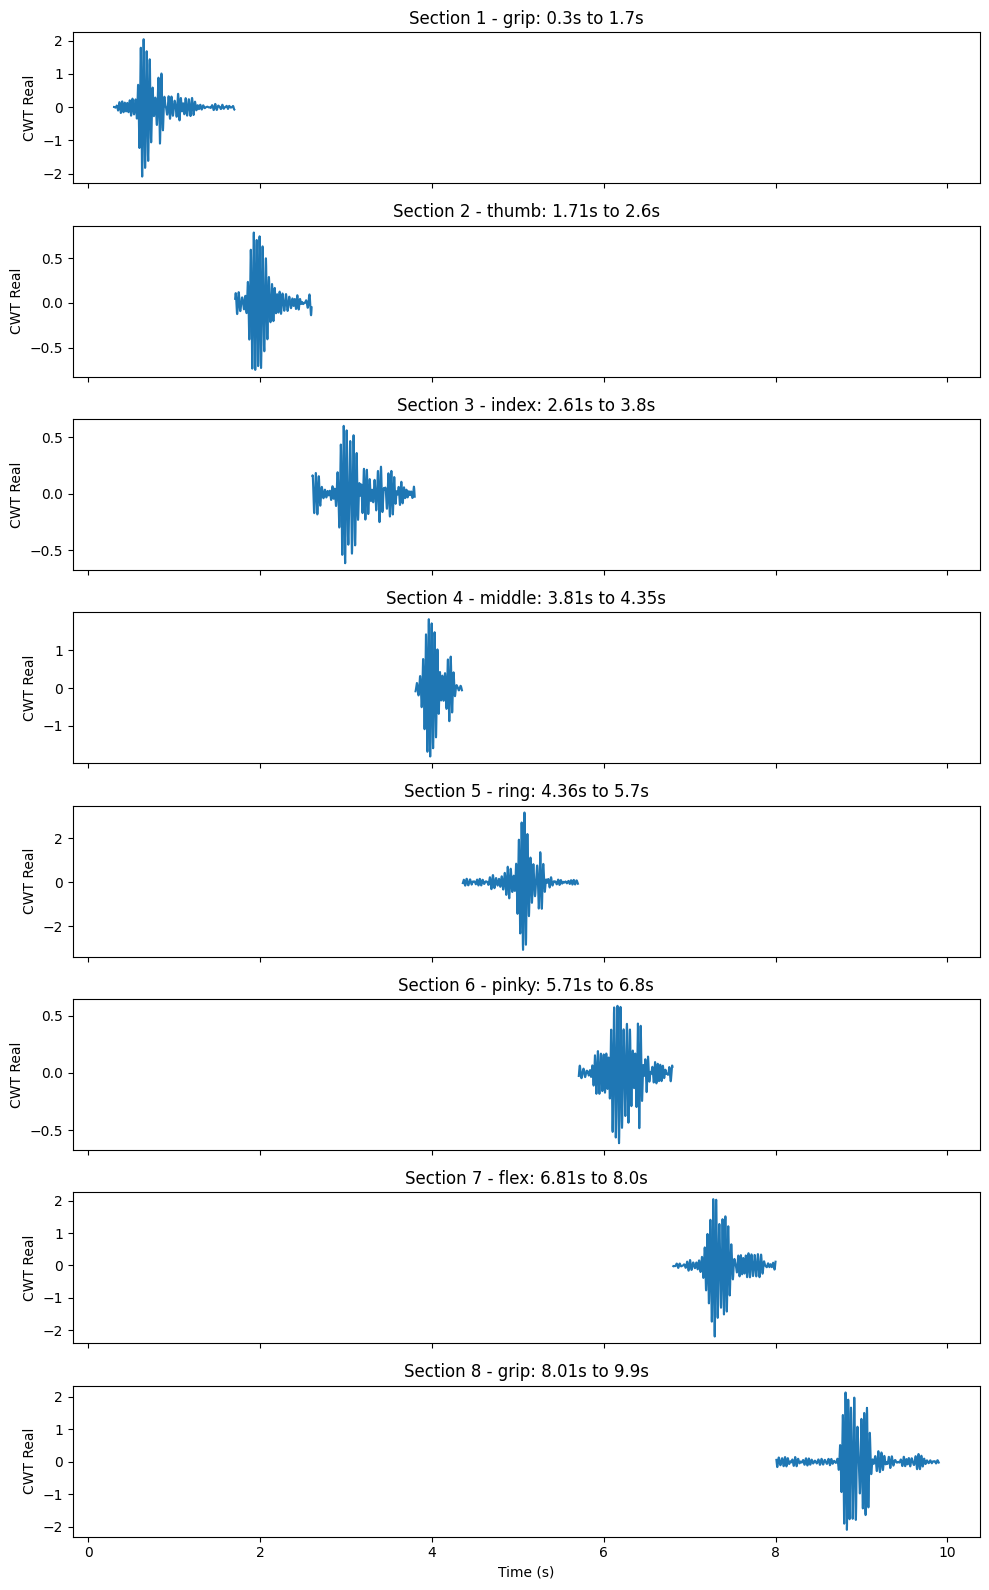

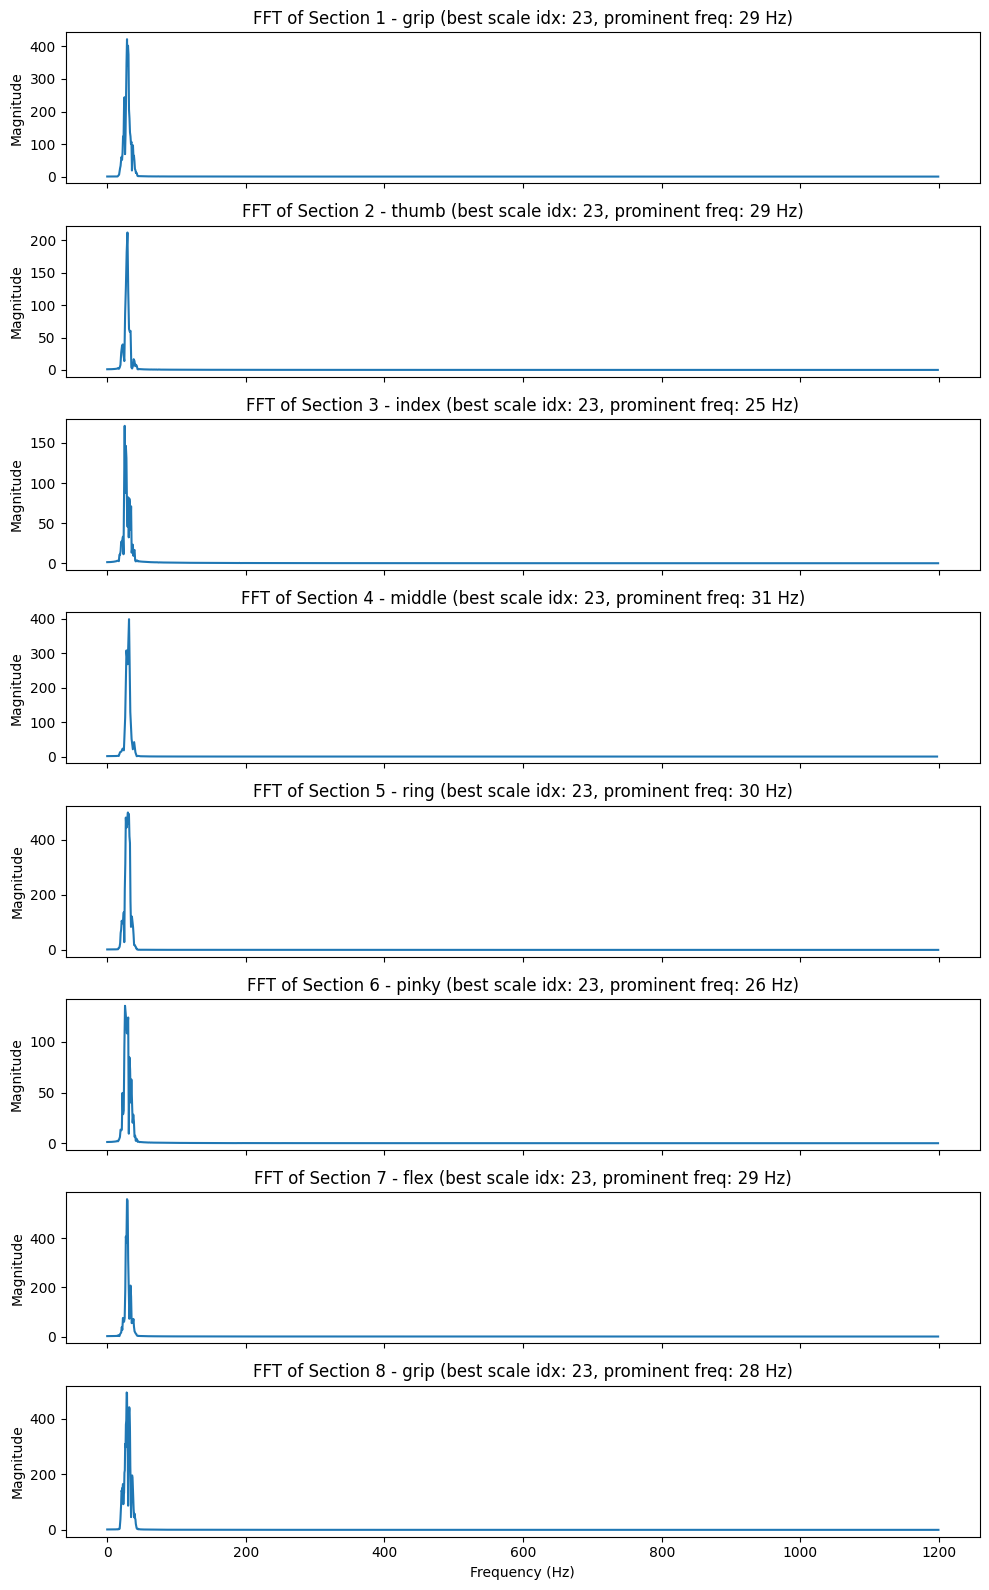

In [ ]:
# Cut the real part of CWT into 8 sections based on time intervals and names

sections = [
    (0.3, 1.7),
    (1.71, 2.6),
    (2.61, 3.8),
    (3.81, 4.35),
    (4.36, 5.7),
    (5.71, 6.8),
    (6.81, 8.0),
    (8.01, 9.9)
]
section_names = [
    "grip",
    "thumb",
    "index",
    "middle",
    "ring",
    "pinky",
    "flex",
    "grip"
]

real_cwt = np.real(cwtmatr[best_scale_idx, :])
real_cwt = real_cwt[100:]  # Drop first 100 samples to match t length
sectioned_cwt = []

for i, ((start, end), name) in enumerate(zip(sections, section_names), 1):
    mask = (t >= start) & (t <= end)
    sectioned_cwt.append(real_cwt[mask])
    print(f"Section {i} ({name}): {start}s to {end}s, samples: {np.sum(mask)}")

# Example: plot all sections
fig, axs = plt.subplots(8, 1, figsize=(10, 16), sharex=True)
for i, ((start, end), name) in enumerate(zip(sections, section_names)):
    mask = (t >= start) & (t <= end)
    axs[i].plot(t[mask], real_cwt[mask])
    axs[i].set_title(f"Section {i+1} - {name}: {start}s to {end}s")
    axs[i].set_ylabel("CWT Real")
axs[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

# FFT for all cut sections of the real part of CWT
section_fft_data = []
section_fft_freqs = []

for i, ((start, end), name) in enumerate(zip(sections, section_names), 1):
    mask = (t >= start) & (t <= end)
    section = real_cwt[mask]
    n = len(section)
    if n > 0:
        fft_signal = np.fft.fft(section)
        fft_freq = np.fft.fftfreq(n, d=1/fs)
        section_fft_data.append(np.abs(fft_signal)[:n//2])
        section_fft_freqs.append(fft_freq[:n//2])
    else:
        section_fft_data.append([])
        section_fft_freqs.append([])

# Plot FFTs for all sections
fig, axs = plt.subplots(8, 1, figsize=(10, 16), sharex=True)
for i, (fft_freq, fft_data) in enumerate(zip(section_fft_freqs, section_fft_data)):
    axs[i].plot(fft_freq, fft_data)
        # Find most prominent frequency
    max_idx = np.argmax(fft_data)
    prominent_freq = fft_freq[max_idx]
    axs[i].set_title(f"FFT of Section {i+1} - {section_names[i]} (best scale idx: {best_scale_idx}, most prominent freq: {prominent_freq:.0f} Hz)")
    # axs[i].set_title(f"FFT of Section {i+1} - {section_names[i]}")
    axs[i].set_ylabel("Magnitude")
axs[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()

Best scale chosen for each section

In [46]:
filtered_signal = filtered_signal[100:]

Section 1 (grip): 0.3s to 1.7s, samples: 3361, best scale idx: 22, best freq: 28.0 Hz
Section 2 (thumb): 1.71s to 2.6s, samples: 2137, best scale idx: 22, best freq: 28.0 Hz
Section 3 (index): 2.61s to 3.8s, samples: 2857, best scale idx: 19, best freq: 25.0 Hz
Section 4 (middle): 3.81s to 4.35s, samples: 1297, best scale idx: 24, best freq: 30.0 Hz
Section 5 (ring): 4.36s to 5.7s, samples: 3217, best scale idx: 23, best freq: 29.0 Hz
Section 6 (pinky): 5.71s to 6.8s, samples: 2617, best scale idx: 24, best freq: 30.0 Hz
Section 7 (flex): 6.81s to 8.0s, samples: 2857, best scale idx: 22, best freq: 28.0 Hz
Section 8 (grip): 8.01s to 9.9s, samples: 4537, best scale idx: 23, best freq: 29.0 Hz


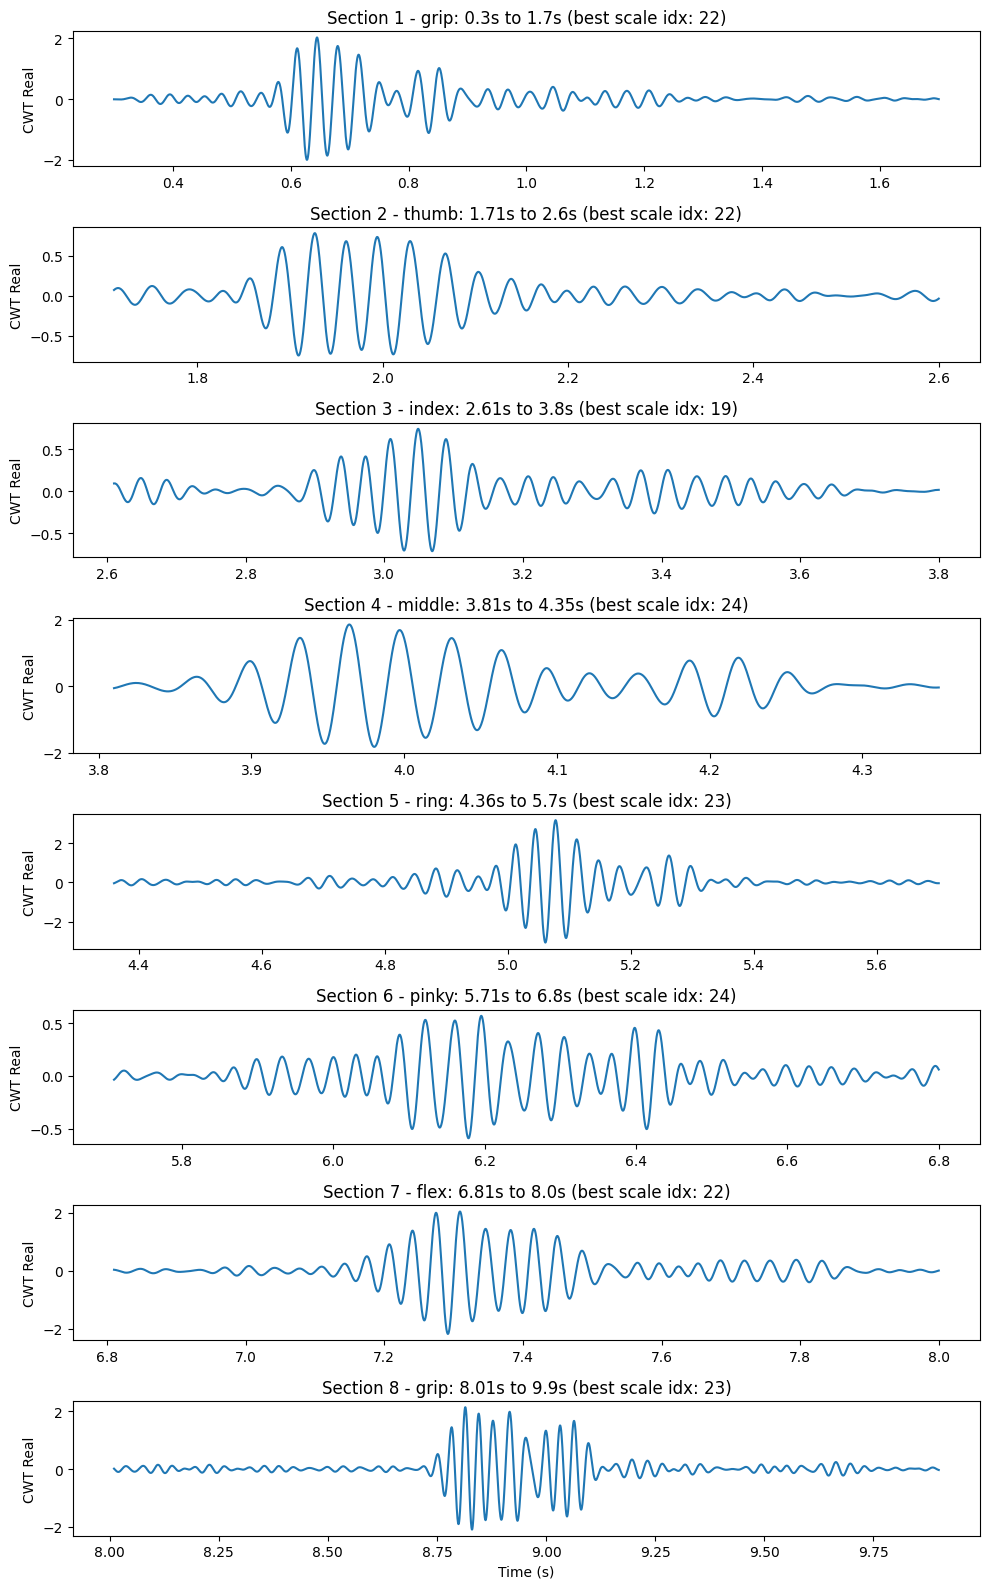

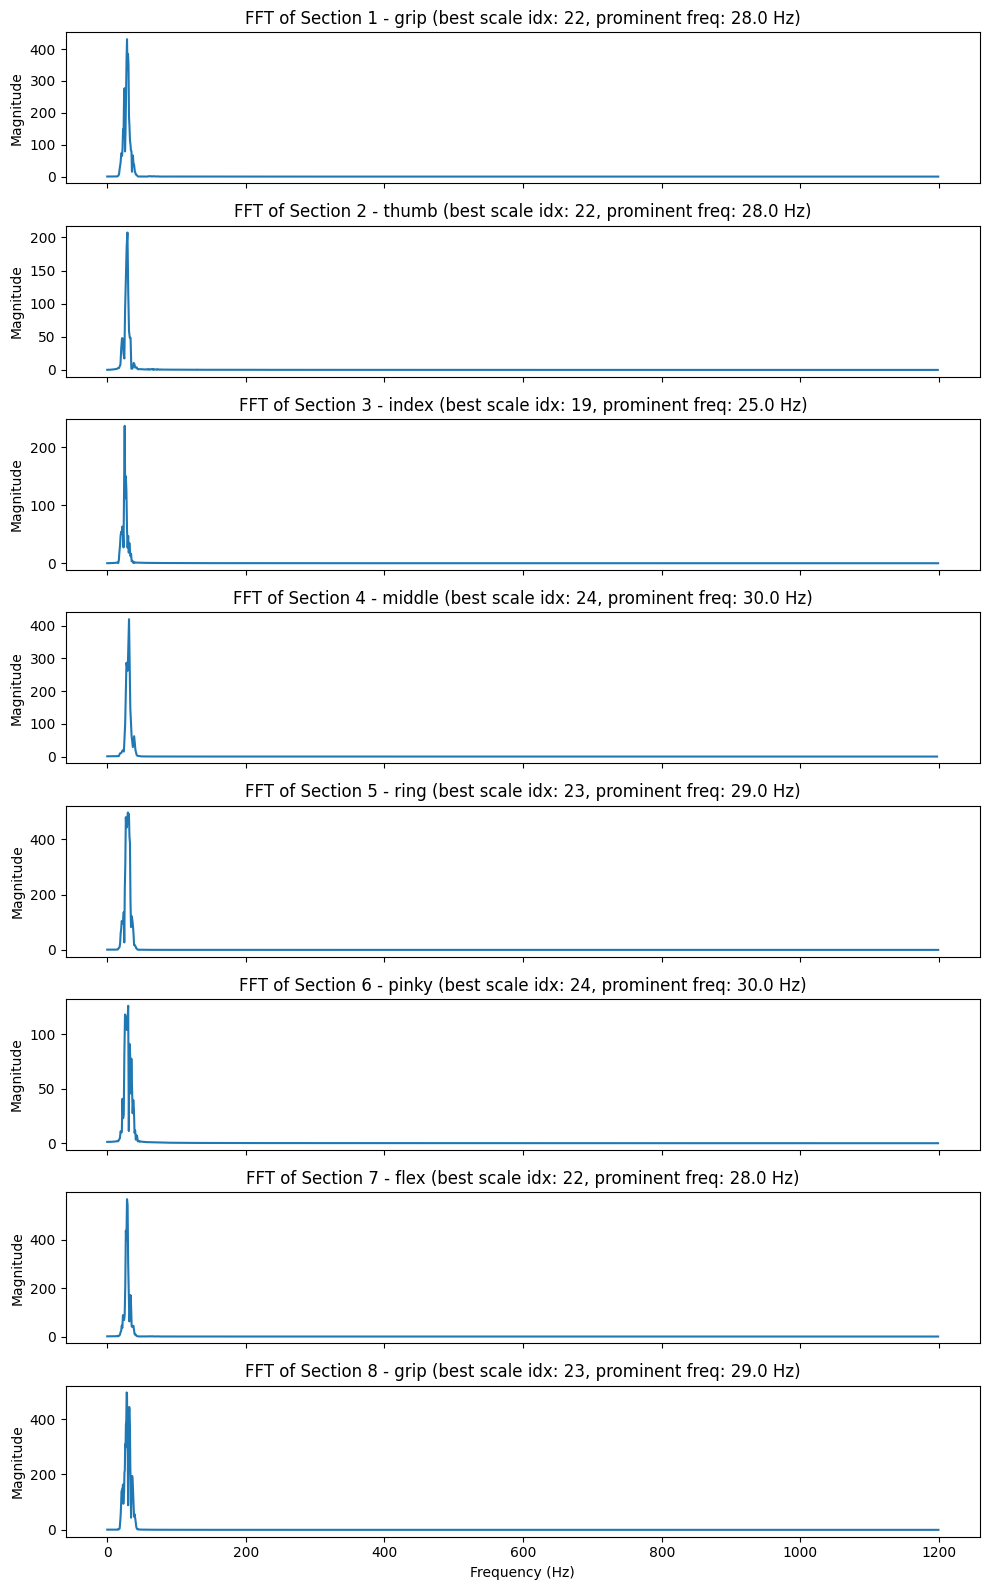

In [ ]:
# Cut the real part of CWT into 8 sections based on time intervals and names
# Select best scale individually for each section

sections = [
    (0.3, 1.7),
    (1.71, 2.6),
    (2.61, 3.8),
    (3.81, 4.35),
    (4.36, 5.7),
    (5.71, 6.8),
    (6.81, 8.0),
    (8.01, 9.9)
]
section_names = [
    "grip",
    "thumb",
    "index",
    "middle",
    "ring",
    "pinky",
    "flex",
    "grip"
]

sectioned_cwt = []
best_scales = []
best_freq_per_section = []

# Extract sections and find best scale for each
for i, ((start, end), name) in enumerate(zip(sections, section_names), 1):
    mask = (t >= start) & (t <= end)
    section_signal = filtered_signal[mask]
    
    # Compute CWT for this section
    dt = 1/fs
    section_cwtmatr, section_freqs = pywt.cwt(section_signal, scales, wavelet, sampling_period=dt)
    
    # Find best scale for this section
    mean_abs = np.mean(np.abs(section_cwtmatr), axis=1)
    section_best_scale_idx = np.argmax(mean_abs)
    best_scales.append(section_best_scale_idx)
    
    # Extract real part using best scale for this section
    section_real_cwt = np.real(section_cwtmatr[section_best_scale_idx, :])
    sectioned_cwt.append(section_real_cwt)
    best_freq_per_section.append(section_freqs[section_best_scale_idx])
    
    print(f"Section {i} ({name}): {start}s to {end}s, samples: {np.sum(mask)}, best scale idx: {section_best_scale_idx}, best freq: {section_freqs[section_best_scale_idx]:.1f} Hz")

# Plot all sections with their individually selected best scales
fig, axs = plt.subplots(8, 1, figsize=(10, 16), sharex=False)
for i, ((start, end), name) in enumerate(zip(sections, section_names)):
    mask = (t >= start) & (t <= end)
    t_section = t[mask]
    axs[i].plot(t_section, sectioned_cwt[i])
    axs[i].set_title(f"Section {i+1} - {name}: {start}s to {end}s (best scale idx: {best_scales[i]})")
    axs[i].set_ylabel("CWT Real")
axs[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

# FFT for all cut sections of the real part of CWT
section_fft_data = []
section_fft_freqs = []

for i, ((start, end), name) in enumerate(zip(sections, section_names), 1):
    section = sectioned_cwt[i-1]
    n = len(section)
    if n > 0:
        fft_signal = np.fft.fft(section)
        fft_freq = np.fft.fftfreq(n, d=1/fs)
        section_fft_data.append(np.abs(fft_signal)[:n//2])
        section_fft_freqs.append(fft_freq[:n//2])
    else:
        section_fft_data.append([])
        section_fft_freqs.append([])

# Plot FFTs for all sections
fig, axs = plt.subplots(8, 1, figsize=(10, 16), sharex=True)
for i, (fft_freq, fft_data) in enumerate(zip(section_fft_freqs, section_fft_data)):
    axs[i].plot(fft_freq, fft_data)
    axs[i].set_title(f"FFT of Section {i+1} - {section_names[i]} (best scale idx: {best_scales[i]}, most prominent freq: {best_freq_per_section[i]:.1f} Hz)")
    axs[i].set_ylabel("Magnitude")
axs[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()